# Train test — 1D Harmonic Oscillator

Ground truth: $E_0 = \frac{1}{2}\hbar\omega = 0.5$ (units $\hbar = m = 1$, $\omega = 1$).

Model: `mlp-fourth-decay`, which outputs $\log\psi = \text{MLP}(x) - \alpha\,x^4$ directly — a log-model with a Gaussian-like envelope that ensures decay at large $x$.

In [56]:
import sys
sys.path.insert(0, '../src')

import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import numpy as np

from qvarnet.train import train
from qvarnet.models.exponential import LogExponentialMLPwithGaussianPenalty
from qvarnet.models.deep_set import DeepSet
from qvarnet.models.analytic import CalogeroSutherlandAnalyticModel
from qvarnet.hamiltonian.continuous import CalogeroSutherlandHamiltonian

## Setup

In [57]:
# System
N_PARTICLES = 5
DIM        = 1
N_CHAINS   = 10_000
DoF        = N_PARTICLES * DIM
SHAPE      = (N_CHAINS, DoF)
CHAIN_LENGTH = 50

# mlp-fourth-decay outputs log|ψ| directly
# model = LogExponentialMLPwithGaussianPenalty(architecture=[DoF, 500, 1])
model = CalogeroSutherlandAnalyticModel(lambda_init=0.2)
# model = DeepSet(phi_hidden_architecture=[50], F_hidden_architecture=[2], hidden_internal_dimension= 100, n_particles=N_PARTICLES)
IS_LOG_MODEL = True

# Hamiltonian
hamiltonian = CalogeroSutherlandHamiltonian(L = 0.1, epsilon = 1e-10, omega_trap=1.0)
# hamiltonian = NN_OscillatorHamiltonian()

# Optimizer
optimizer = optax.adam(learning_rate=0.001)

# Sampler params
sampler_params = {
    "step_size": 0.5,
    "chain_length": CHAIN_LENGTH+1,
    "thermalization_steps": CHAIN_LENGTH,
    "thinning_factor": 1,
    "PBC": 40.0,
}

N_EPOCHS = 10_000

## Train

In [58]:
history, cm_mean, cm_std = train(
    n_epochs=N_EPOCHS,
    shape=SHAPE,
    model=model,
    optimizer=optimizer,
    sampler_params=sampler_params,
    hamiltonian=hamiltonian,
    rng_seed=42,
    warm_walkers=True,
    is_update_step_size=True,
    is_log_model=IS_LOG_MODEL,
)

100%|██████████| 10000/10000 [00:33<00:00, 300.03it/s, E=69.15, sigma_E=1951.71]        


## Extract history

In [59]:
energies    = np.array([s.energy for s in history])/N_PARTICLES
stds        = np.array([s.std    for s in history])/N_PARTICLES
acc_rates   = np.array([float(jnp.mean(s.acceptance_rate)) for s in history])
step_sizes  = np.array([float(s.step_size) for s in history])
cm_mean_arr = np.array([float(x) for x in cm_mean])
cm_std_arr  = np.array([float(x) for x in cm_std])

steps   = np.arange(len(history))
E_EXACT = (1+hamiltonian.L*(N_PARTICLES-1))

## Plots

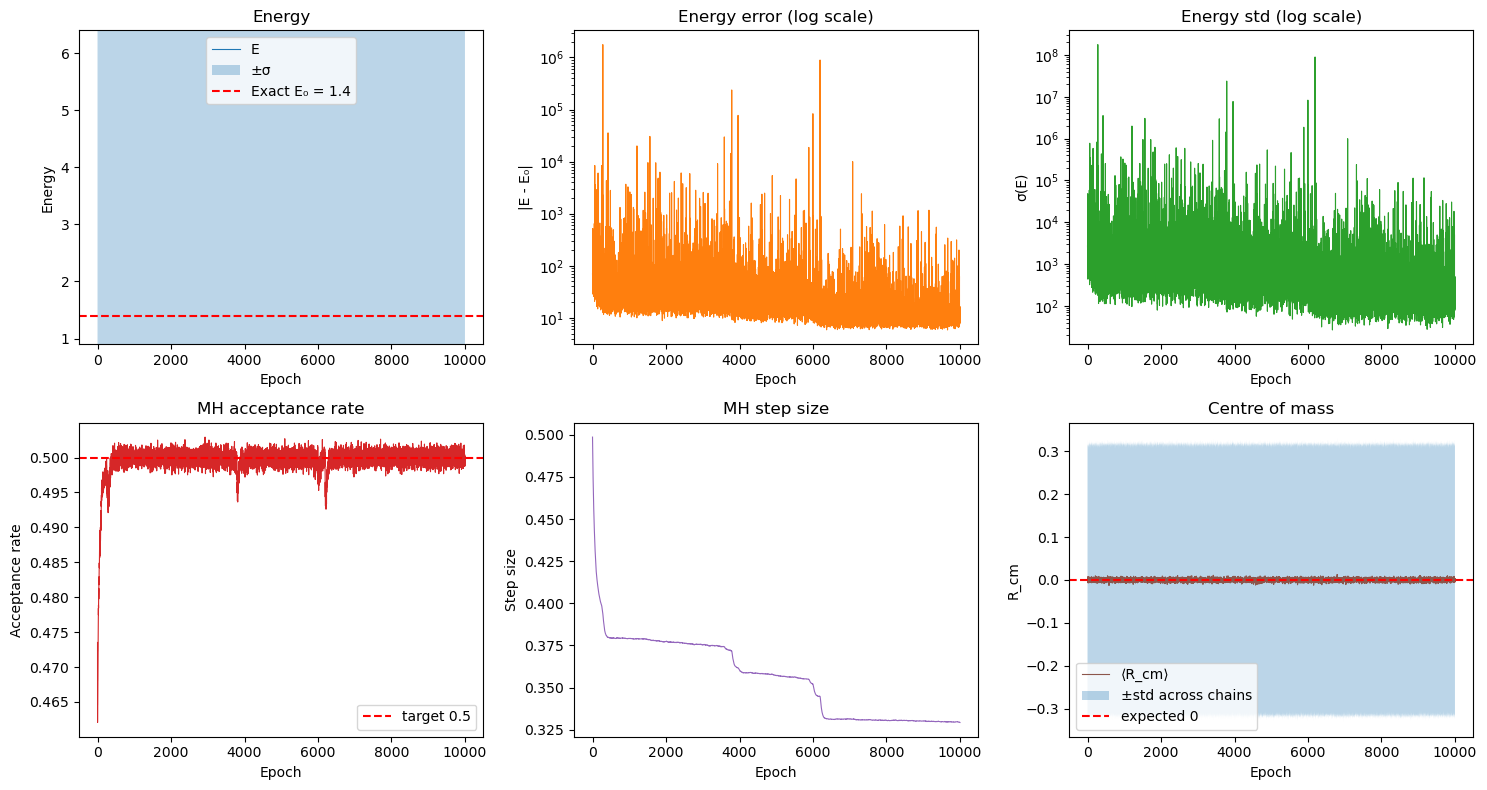

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# fig.suptitle('1D Harmonic Oscillator — mlp-fourth-decay (log model)', fontsize=14)

# --- Energy ---
ax = axes[0, 0]
ax.plot(steps, energies, lw=0.8, label='E')
ax.fill_between(steps, energies - stds, energies + stds, alpha=0.3, label='±σ')
ax.axhline(E_EXACT, color='red', ls='--', label=f'Exact E₀ = {E_EXACT}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Energy')
ax.set_title('Energy')
ax.set_ylim(E_EXACT - 0.5, E_EXACT + 5.0)
ax.legend()

# --- Energy error ---
ax = axes[0, 1]
ax.semilogy(steps, np.abs(energies - E_EXACT), lw=0.8, color='C1')
ax.set_xlabel('Epoch')
ax.set_ylabel('|E - E₀|')
ax.set_title('Energy error (log scale)')

# --- Std ---
ax = axes[0, 2]
ax.semilogy(steps, stds, lw=0.8, color='C2')
ax.set_xlabel('Epoch')
ax.set_ylabel('σ(E)')
ax.set_title('Energy std (log scale)')

# --- Acceptance rate ---
ax = axes[1, 0]
ax.plot(steps, acc_rates, lw=0.8, color='C3')
ax.axhline(0.5, color='red', ls='--', label='target 0.5')
ax.set_xlabel('Epoch')
ax.set_ylabel('Acceptance rate')
ax.set_title('MH acceptance rate')
ax.legend()

# --- Step size ---
ax = axes[1, 1]
ax.plot(steps, step_sizes, lw=0.8, color='C4')
ax.set_xlabel('Epoch')
ax.set_ylabel('Step size')
ax.set_title('MH step size')

# --- Centre of mass ---
ax = axes[1, 2]
ax.plot(steps, cm_mean_arr, lw=0.8, color='C5', label='⟨R_cm⟩')
ax.fill_between(steps,
                cm_mean_arr - cm_std_arr,
                cm_mean_arr + cm_std_arr,
                alpha=0.3, label='±std across chains')
ax.axhline(0.0, color='red', ls='--', label='expected 0')
ax.set_xlabel('Epoch')
ax.set_ylabel('R_cm')
ax.set_title('Centre of mass')
ax.legend()

plt.tight_layout()
# plt.savefig('train_test_results_warm_walkers.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

In [61]:
TAIL = 1
final_E   = energies[-TAIL:].mean()
final_std = stds[-TAIL:].mean()
error     = abs(final_E - E_EXACT)

print(f"Exact E₀           : {E_EXACT:.6f}")
print(f"Final E (last {TAIL})  : {final_E:.6f} ± {final_std:.6f}")
print(f"|E - E₀|           : {error:.6f}")
print(f"Relative error     : {error/E_EXACT * 100:.3f}%")
print(f"Final accept rate  : {acc_rates[-TAIL:].mean():.3f}")
print(f"Final step size    : {step_sizes[-1]:.4f}")
print(f"Final ⟨R_cm⟩       : {cm_mean_arr[-TAIL:].mean():.4f}")
print(f"Final std(R_cm)    : {cm_std_arr[-TAIL:].mean():.4f}")
print(f"Final variational error : {(final_std)/final_E * 100:.6f}")

Exact E₀           : 1.400000
Final E (last 1)  : 11.790590 ± 228.935623
|E - E₀|           : 10.390591
Relative error     : 742.185%
Final accept rate  : 0.500
Final step size    : 0.3292
Final ⟨R_cm⟩       : 0.0027
Final std(R_cm)    : 0.3189
Final variational error : 1941.680664


In [62]:
def sample_and_final_statistics(N_SAMPLES=10_000):
    from qvarnet.sampling_step import sample_and_process
    from qvarnet.probability import build_prob_fn

    model_params = history[-1].params
    prob_fn = build_prob_fn(model.apply, is_log_model=IS_LOG_MODEL)

    N_CHAINS_SAMP = N_SAMPLES
    CHAIN_LENGTH_SAMP = 1000


    final_samples, _, _ = sample_and_process(
        key=jax.random.PRNGKey(999),
        prob_fn=prob_fn,
        prob_params=model_params,
        init_positions=jnp.zeros((N_CHAINS_SAMP, N_PARTICLES * DIM)),
        step_size=float(history[-1].step_size),
        n_chains=N_CHAINS_SAMP,
        DoF=N_PARTICLES * DIM,
        n_steps=CHAIN_LENGTH_SAMP + 1,
        burn_in=CHAIN_LENGTH_SAMP-500,
        thinning=10,
        PBC=sampler_params["PBC"],
        is_log_prob=IS_LOG_MODEL,
        # uniform omitted — default is False, and passing it causes a
        # TracerBoolConversionError because it is missing from static_argnames
    )

    # local_energy already batches internally (vmap inside kinetic_term_log_wavefunction),
    # so pass the full sample array directly — do NOT wrap in an outer vmap
    final_energies = hamiltonian.local_energy(model_params, final_samples, model.apply, IS_LOG_MODEL)
    final_energy_mean = jnp.mean(final_energies)
    final_energy_std  = jnp.std(final_energies)

    final_cm      = jnp.mean(final_samples, axis=1)   # R_cm per sample
    final_cm_mean = jnp.mean(final_cm)
    final_cm_std  = jnp.std(final_cm)

    print(f"Final E (new samples)      : {final_energy_mean:.6f} ± {final_energy_std:.6f}")
    print(f"Final ⟨R_cm⟩ (new samples) : {final_cm_mean:.6f} ± {final_cm_std:.6f}")

sample_and_final_statistics(5_000)

Final E (new samples)      : 180.082993 ± 52673.914062
Final ⟨R_cm⟩ (new samples) : 0.000664 ± 0.316639


### Count how many parameters the model has

In [63]:
def count_parameters(params):
    return sum(jnp.prod(jnp.array(p.shape)) for p in jax.tree_util.tree_leaves(params))

count_parameters(history[0].params)

print(history[-1].params)

{'params': {'lam': Array(0.3988157, dtype=float32)}}


In [64]:
history[-1].params["params"]["lam"]

Array(0.3988157, dtype=float32)

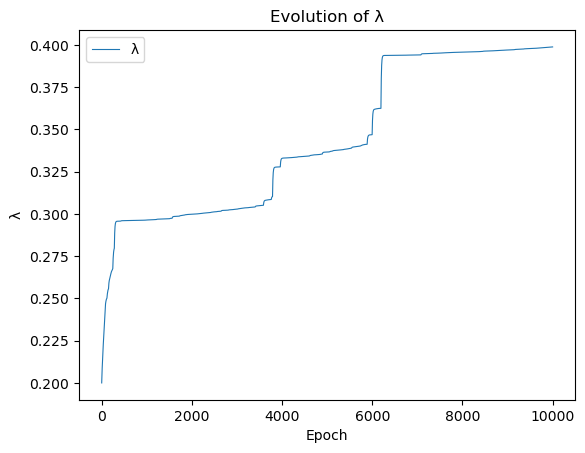

In [65]:
plt.plot(steps, [history[i].params["params"]["lam"] for i in range(len(history))], lw=0.8, label='λ')
plt.xlabel('Epoch')
plt.ylabel('λ')
plt.title('Evolution of λ')
plt.legend()
plt.show()

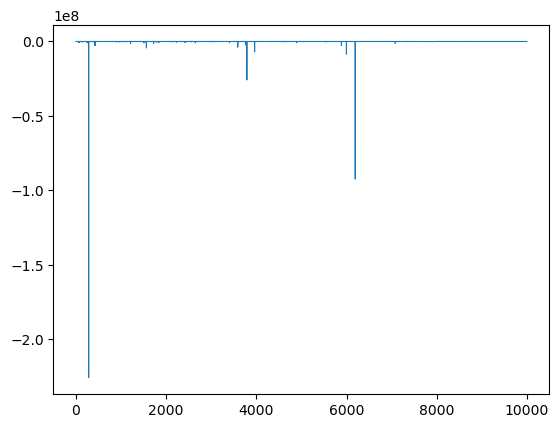

In [66]:
plt.plot(steps, [history[i].grads["params"]["lam"] for i in range(len(history))], lw=0.8, label='∇λ')

In [ ]:
history[0].grads

{'params': {'lam': Array(-4654.906, dtype=float32)}}

: 